# ML code

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


from scipy.optimize import minimize


# Column name mapping

In [3]:
def mapping_column_name(df, case='any', mapping_df=None, verbosity=1):
    if mapping_df is None:
        default_column_name_mapping_file_path = 'column_name_mapping.csv'
        try:
            mapping_df=pd.read_csv(default_column_name_mapping_file_path)
        except:
            raise Exception(f'The default column name file for mapping "{default_column_name_mapping_file_path}" was not found')

    mapping_df = mapping_df.query('use_case == @case')
    if len(mapping_df) == 0:
        raise Exception(f'The mapping dataframe does not contains the case: {case}')
    
    df_mapped = df.copy()
    columns_to_map = df.columns 
    if len(columns_to_map) != len(set(columns_to_map)):
        unique_columns = set(columns_to_map)
        for item in unique_columns:
            columns_to_map.to_list().remove(item)
        raise Exception(f'The column names should be unique but duplicate(s) are found: {set(columns_to_map)}')

    mapping_dictionary = dict()
    for col in columns_to_map:
        mask = mapping_df.apply(lambda row: row.astype(str).str.fullmatch(col, case=False, na=False).any(), axis=1)
        mapping_found = mapping_df[mask]
        if len(mapping_found) == 1:
            df_mapped.rename(columns={col : mapping_found['standard_name'].astype(str).iloc[0]}, inplace=True)
            if verbosity > 0: print(f'The column {col} was renamed to {mapping_found["standard_name"].iloc[0]}')
            mapping_dictionary[col] = mapping_found['standard_name'].astype(str).iloc[0]
        elif len(mapping_found) > 1:
            raise Exception(f'The column {col} has multiple mapping toward the following standard name: {mapping_found["standard_name"].to_list()}')
        elif len(mapping_found) == 0:
            mapping_dictionary[col] = col
            if verbosity > 1: print(f'The column {col} has no mapping found')
  
    return df_mapped, mapping_dictionary

df = pd.DataFrame([[2, 2.1, 2.2], [3, 3.1, 3.2]], columns=['Cycle', 'TiCl4_Pulse', 'TiCl4_Purge'])
df, _ = mapping_column_name(df,)
df

The column Cycle was renamed to cycle
The column TiCl4_Pulse was renamed to ticl4_pulse_time
The column TiCl4_Purge was renamed to ticl4_purge_time


,cycle,ticl4_pulse_time,ticl4_purge_time
0,2,2.1,2.2
1,3,3.1,3.2


# Create polynomial features for multiple layer process

In [4]:
df = pd.DataFrame([[2, 2.1, 2.2, 0.01], [3, 3.1, 3.2, 0.07]], columns=['Cycle', 'TiCl4_Pulse', 'Temperature', 'Vfb'])
df, _ = mapping_column_name(df)

col_for_poly_feature = df.columns.to_list()
col_for_poly_feature.remove('vfb')

print(col_for_poly_feature)
poly_feature_creator = PolynomialFeatures(degree=2,interaction_only=True, include_bias=False)
poly_feature_creator.fit(df[col_for_poly_feature])

poly_feature = pd.DataFrame(poly_feature_creator.transform(df[col_for_poly_feature]), columns=poly_feature_creator.get_feature_names_out())
poly_feature
# pd.DataFrame(

The column Cycle was renamed to cycle
The column TiCl4_Pulse was renamed to ticl4_pulse_time
The column Temperature was renamed to temperature
The column Vfb was renamed to vfb
['cycle', 'ticl4_pulse_time', 'temperature']


,cycle,ticl4_pulse_time,temperature,cycle ticl4_pulse_time,cycle temperature,ticl4_pulse_time temperature
0,2.0,2.1,2.2,4.2,4.4,4.62
1,3.0,3.1,3.2,9.3,9.6,9.92


In [5]:
# search with randomized starts
solutions = []

def objective(x):
    pred = model.predict([x])[0]
    return abs(pred - y_target)


for i in range(50000):
    # random starts as initial guess
    temp = np.random.uniform(80,150)
    time = np.random.uniform(1,10)
    
    result = minimize(objective, x0=[temp,time], bounds=[(80,150),(1,10)])
    result.x # the optimal input
    result.fun # the minimum objective value found

    if abs(result.fun) < 0.01:
        solutions.append([result.fun, result.fun+y_target,  temp,time])

NameError: name 'model' is not defined

# Undirected Graph

In [7]:

class SingleRowFeatureStore:
    def __init__(self, df: pd.DataFrame):
        # 確保傳入的是 DataFrame
        self.df = df.copy()

    # ==========================================
    # 核心機制：內外分離
    # ==========================================
    
    def _get_series(self, feature_name: str) -> pd.Series:
        """【內部專用】回傳 Series，讓變數之間的加減乘除可以順利進行"""
        if feature_name not in self.df.columns:
            compute_method = getattr(self, f"_compute_{feature_name}", None)
            if not compute_method:
                raise ValueError(f"缺少變數或計算邏輯: {feature_name}")
            
            print(f"[系統] 正在計算: {feature_name}...")
            # 把計算結果存回 DataFrame 的新欄位中
            self.df[feature_name] = compute_method()
            
        return self.df[feature_name]

    def get_feature_as_df(self, feature_name: str) -> pd.DataFrame:
        """【外部專用】永遠回傳 2D 的 DataFrame (利用雙中括號)"""
        # 呼叫內部方法確保該變數已被計算並存在於 df 中
        self._get_series(feature_name)
        
        # 使用雙中括號 [[ ]] 回傳 DataFrame 格式
        return self.df[[feature_name]]

    # ==========================================
    # 變數計算邏輯區 (N級變數呼叫比他低級的變數)
    # ==========================================

    def _compute_total_income(self):
        # 【第二級變數】
        # 內部計算一律使用 _get_series，確保是 Series 相加，不會產生 NaN
        return self._get_series('base_salary') + self._get_series('bonus')

    def _compute_income_per_age(self):
        # 【第三級變數】
        return self._get_series('total_income') / self._get_series('age')


# --- 測試與使用 ---

# 建立一個只有 1 個 row 的 DataFrame
raw_data_1_row = pd.DataFrame({
    'base_salary': [50000],
    'bonus': [10000],
    'age': [30]
})

store = SingleRowFeatureStore(raw_data_1_row)

print("--- 取得第三級變數 ---")
# 呼叫外部方法
result_df = store.get_feature_as_df('income_per_age')

print("\n[結果印出]")
print(result_df)

print("\n[檢查型別]")
print("回傳的型別是:", type(result_df)) # 確認是 DataFrame，而不是 Series



--- 取得第三級變數 ---
[系統] 正在計算: income_per_age...
[系統] 正在計算: total_income...

[結果印出]
   income_per_age
0          2000.0

[檢查型別]
回傳的型別是: <class 'pandas.core.frame.DataFrame'>


# Performance Plot

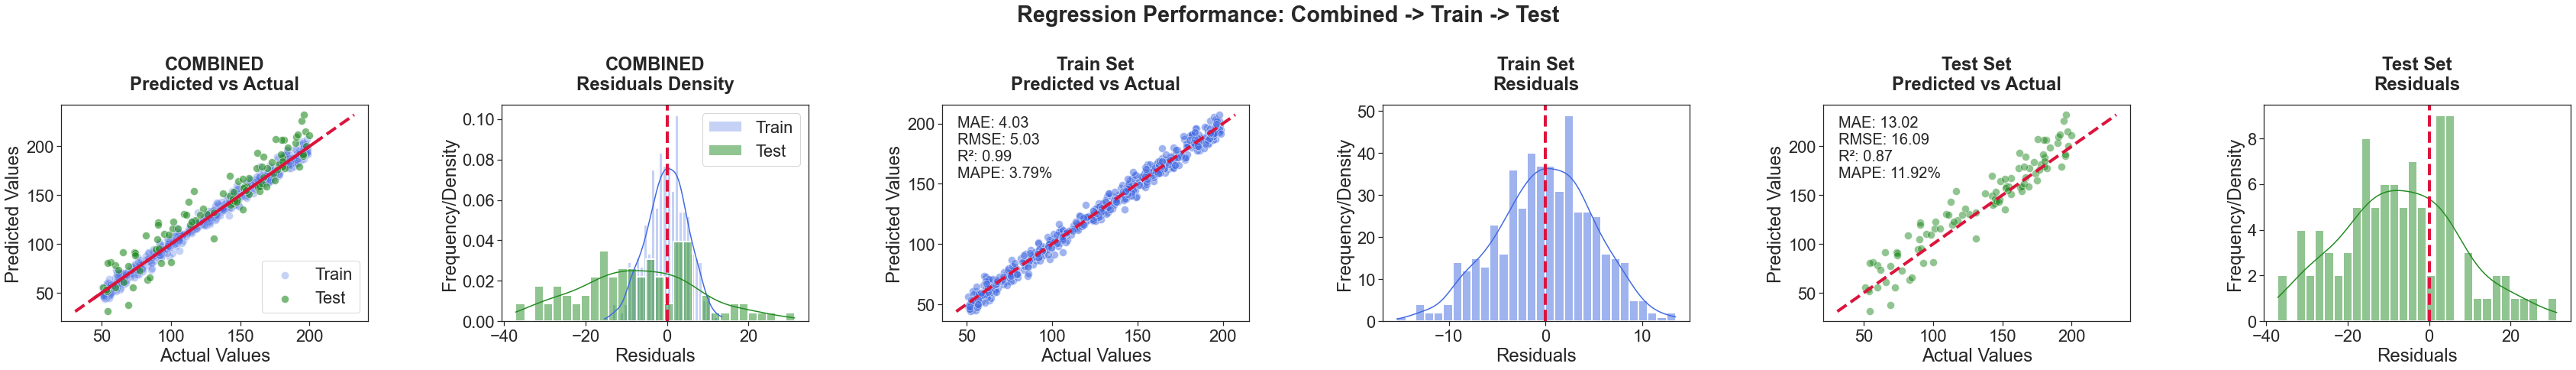

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def get_metrics_text(y_true, y_pred):
    """計算指標並回傳格式化字串"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}\nMAPE: {mape * 100:.2f}%"

def plot_horizontal_performance(y_train_true, y_train_pred, y_test_true, y_test_pred, save_path=None):
    """
    繪製 1x6 的橫向迴歸模型評估圖表。
    順序：[混合散佈圖] [混合直方圖] [Train散佈圖] [Train直方圖] [Test散佈圖] [Test直方圖]
    """
    # 1. 取消背景網格 (style="ticks")，並將全域字體放大一倍 (font_scale=2)
    sns.set_theme(style="ticks", font_scale=2)
    
    # 2. 建立 1x6 的畫布，因為一字排開，寬度需要設得非常大 (例如 48x8)
    fig, axes = plt.subplots(1, 6, figsize=(48, 8))
    fig.suptitle('Regression Performance: Combined -> Train -> Test', fontweight='bold', y=0.9)

    train_color = 'royalblue'
    test_color = 'forestgreen'

    # ==========================================
    # 內部輔助函數 (同步放大點的大小與線條粗細)
    # ==========================================
    def draw_scatter(ax, yt, yp, title, color, label=None, alpha=0.5):
        # s=100 讓點變大，才不會被放大的字體吃掉
        sns.scatterplot(x=yt, y=yp, ax=ax, color=color, alpha=alpha, label=label, s=100)
        min_val, max_val = min(np.min(yt), np.min(yp)), max(np.max(yt), np.max(yp))
        # linewidth=4 加粗紅色對角線
        ax.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=4)
        ax.set_title(title, fontweight='bold', pad=20)
        ax.set_xlabel('Actual Values')
        ax.set_ylabel('Predicted Values')

    def draw_hist(ax, yt, yp, title, color, label=None, alpha=0.5, stat='count'):
        sns.histplot(yt - yp, kde=True, ax=ax, color=color, bins=30, alpha=alpha, label=label, stat=stat, linewidth=2)
        ax.axvline(x=0, color='crimson', linestyle='--', linewidth=4)
        ax.set_title(title, fontweight='bold', pad=20)
        ax.set_xlabel('Residuals')
        ax.set_ylabel('Frequency/Density')

    # ==========================================
    # 圖 1 & 圖 2: 把混合圖 (Combined) 放在最前面
    # ==========================================
    # [axes 0] 疊加散佈圖
    draw_scatter(axes[0], y_train_true, y_train_pred, 'COMBINED\nPredicted vs Actual', train_color, 'Train', 0.3)
    draw_scatter(axes[0], y_test_true, y_test_pred, 'COMBINED\nPredicted vs Actual', test_color, 'Test', 0.6)
    axes[0].legend(loc='lower right', frameon=True)

    # [axes 1] 疊加殘差圖 
    draw_hist(axes[1], y_train_true, y_train_pred, 'COMBINED\nResiduals Density', train_color, 'Train', 0.3, stat='density')
    draw_hist(axes[1], y_test_true, y_test_pred, 'COMBINED\nResiduals Density', test_color, 'Test', 0.5, stat='density')
    axes[1].legend(loc='upper right', frameon=True)

    # ==========================================
    # 圖 3 到 圖 6: 依序畫出 Train 與 Test 獨立圖
    # ==========================================
    datasets = [
        (2, 'Train Set', y_train_true, y_train_pred, train_color),
        (4, 'Test Set',  y_test_true,  y_test_pred,  test_color)
    ]

    for start_idx, name, yt, yp, color in datasets:
        metrics = get_metrics_text(yt, yp)
        ax_scatter = axes[start_idx]     # 散佈圖位置
        ax_hist = axes[start_idx + 1]    # 直方圖位置
        
        # 畫散佈圖與文字方塊 (明確指定字體大小為 20 以匹配全域放大設定)
        draw_scatter(ax_scatter, yt, yp, f'{name}\nPredicted vs Actual', color)
        ax_scatter.text(0.05, 0.95, metrics, transform=ax_scatter.transAxes, 
                        fontsize=20, va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # 畫殘差直方圖
        draw_hist(ax_hist, yt, yp, f'{name}\nResiduals', color)

    # 3. 強制拉開圖表之間的間距 (w_pad 參數)
    plt.tight_layout(pad=2.0, w_pad=4.0)
    
    # ==========================================
    # 儲存圖片邏輯
    # ==========================================
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ 圖表已成功儲存至: {save_path}")
        
    plt.show()

# --- 測試與使用範例 ---
np.random.seed(42)
y_train_true_mock = np.random.uniform(50, 200, 500)
y_train_pred_mock = y_train_true_mock + np.random.normal(0, 5, 500) 
y_test_true_mock = np.random.uniform(50, 200, 100)
y_test_pred_mock = y_test_true_mock + np.random.normal(5, 15, 100) 

plot_horizontal_performance(y_train_true_mock, y_train_pred_mock, y_test_true_mock, y_test_pred_mock)